## Imports ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import interp1d
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import trapezoid
from scipy import optimize

## Data Load in and Pre-Processing ##

In [15]:
ice_ascii = pd.read_csv('/Users/rafidquayum/Desktop/Research/Wordsworth Lab/Code Files/IOP_2008_ASCIItable.dat.txt', sep=r'\s+', header=None) # Replace with the location of your file on local machine
row_name = ['Wavelength', 'real', 'imaginary']
ice_ascii.columns = row_name



sun_data =  pd.read_csv('/Users/rafidquayum/Desktop/Research/Wordsworth Lab/Code Files/sunum.txt', sep='\t') # Replace with the location of your file on local machine  
sun_array = sun_data.to_numpy()

## Plotting Index of Refraction vs. Wavelength (Warren 2019) ##

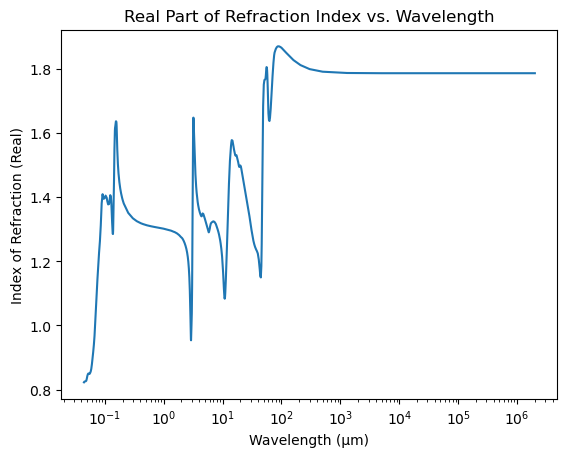

In [17]:
# Plot real part of index of refraction data from Warren 2019

plt.plot(ice_ascii['Wavelength'], ice_ascii['real'])
plt.xscale('log')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Index of Refraction (Real)')

plt.title('Real Part of Refraction Index vs. Wavelength')
plt.show()

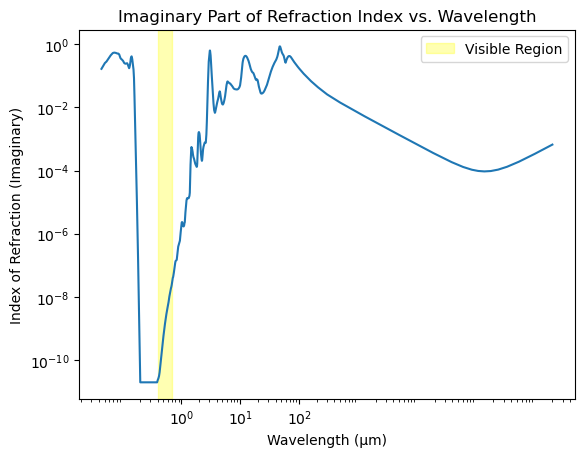

In [19]:
# Plot imaginary part of index of refraction data from Warren 2019, and highlight the visible region

plt.plot(ice_ascii['Wavelength'], ice_ascii['imaginary'])
plt.yscale('log')
plt.xscale('log')
plt.xticks([1, 10, 10**2])
plt.xlabel('Wavelength (µm)')
plt.ylabel('Index of Refraction (Imaginary)')
plt.title('Imaginary Part of Refraction Index vs. Wavelength')

plt.axvspan(0.4, 0.7, color='yellow', alpha=0.3, label='Visible Region')

plt.legend()

plt.show()

## Calculate Absorption coefficient and plot k$_{abs}$ vs $\lambda$ ##

Calculate the absorption coefficient using the following equation:

$$
k_{\text{abs}} = \frac{4 \pi k_{\text{img}}}{\lambda}
$$


In [437]:
k_abs = 4.0*np.pi*ice_ascii['imaginary']/ice_ascii['Wavelength']
k_abs = np.array(k_abs)
k_abs_m = k_abs * 10**6 # Converting the wavelength from microns to meters
ice_wavelength_m = np.array(ice_ascii['Wavelength'])/ (10**6)

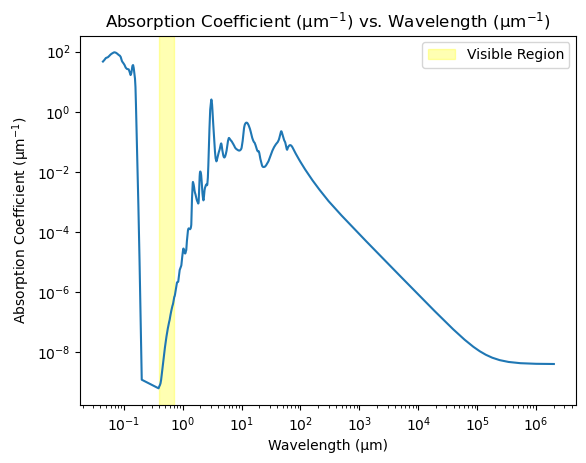

In [439]:
plt.plot(ice_ascii['Wavelength'], k_abs)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Wavelength (µm)')
plt.ylabel(r'Absorption Coefficient (µm$^{-1}$)')
plt.axvspan(0.4, 0.7, color='yellow', alpha=0.3, label='Visible Region')

plt.legend()
plt.title(r'Absorption Coefficient (µm$^{-1}$) vs. Wavelength (µm$^{-1}$)')
plt.show()

## Contamination k set ##

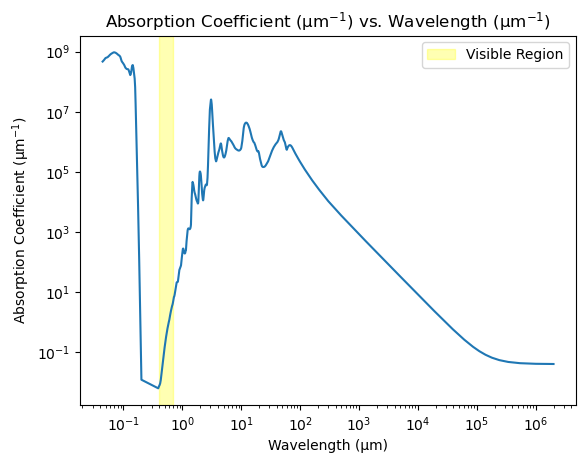

In [442]:
contam_scale = 10
k_abs_contam = k_abs_m.copy()*contam_scale # Creating a copy of the k array for contamination test
# k_abs_contam = np.array([k_abs_m.max() for val in k_abs_m]) # Creating a copy of the k array for contamination test

plt.plot(ice_ascii['Wavelength'], k_abs_contam)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Wavelength (µm)')
plt.ylabel(r'Absorption Coefficient (µm$^{-1}$)')
plt.axvspan(0.4, 0.7, color='yellow', alpha=0.3, label='Visible Region')

plt.legend()
plt.title(r'Absorption Coefficient (µm$^{-1}$) vs. Wavelength (µm$^{-1}$)')
plt.show()

## Sun Absorption Data and Resampling ##

In [444]:
factor_x = 10**-6 # Converts wavelength from microns to m
factor_y = 10**10 # Convert W/cm^2/micron to W/m^2/meters

sun_wavelengths = sun_array[:, 0]  # Original wavelengths
sun_intensities = sun_array[:, 1]  # Original solar intensities

sun_wavelengths_m = sun_wavelengths * factor_x
sun_intensities_m = sun_intensities * factor_y

sun_max = max(sun_wavelengths_m)
sun_min = min(sun_wavelengths_m)

area_original = np.trapz(sun_intensities_m, sun_wavelengths_m) # Verify around 1366 W/m^2

mask_wavelength = (ice_wavelength_m >= sun_min) & (ice_wavelength_m <= sun_max) # Creates a mask so that our wavelengths (from Warren ice data) 
                                                                                # are limited to the wavelengths of the sun array data

sun_ice_m = ice_wavelength_m[mask_wavelength] # Uses mask to mask wavelengths of data to the min and max values of the sun wavelength data

k_abs_m_mask = k_abs_m[mask_wavelength] # Masks wavelengths of absorption coefficient data
k_abs_m_mask_micron = k_abs_m_mask*10**-6 # Convert to microns

# Updates mask for contaminated ice k-values
k_abs_contam_mask = k_abs_contam[mask_wavelength]
k_abs_contam_micron = k_abs_m_mask*10**-6 # Convert to microns

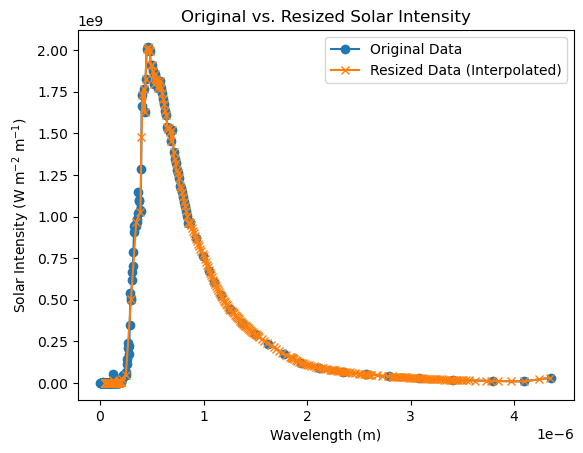

Original sun_array shape: (200, 2)
Resized sun_array shape: (315, 2)


In [446]:
# Resample the sun array data to have the same length as the visible range of the ice wavelength data (sun_ice_m)

# Create an interpolation function using "linear"
interp_func = interp1d(sun_wavelengths_m, sun_intensities_m, kind='linear', fill_value="extrapolate")

# Interpolate sun data to match wavelengths in sun_ice_m
resampled_intensities = interp_func(sun_ice_m)

# Combine new wavelengths (sun_ice_m) with resampled intensities into resized sun_array
sun_array_resized = np.column_stack((sun_ice_m, resampled_intensities))

# Optional: Plot to visually confirm
plt.plot(sun_wavelengths_m, sun_intensities_m, 'o-', label='Original Data')
plt.plot(sun_array_resized[:, 0], sun_array_resized[:, 1], 'x-', label='Resized Data (Interpolated)')
plt.xlabel('Wavelength (m)')
plt.ylabel(r'Solar Intensity (W m$^{-2}$ m$^{-1}$)')
plt.title('Original vs. Resized Solar Intensity')
plt.legend()
plt.show()

# Confirm resized sun array matches len sun_ice_m
print(f"Original sun_array shape: {sun_array.shape}")
print(f"Resized sun_array shape: {sun_array_resized.shape}")

## Calculating the solar intensity (I) vs $\lambda$ for different ice thickness depths ##

$$
I = I_0 \, e^{-k_{a} t}
$$

In [448]:
t_01 = 0.01
t_1 = 0.1
t1 = 1.0
t10 = 10
t100 = 100
t1000 = 1000

intensity_00_1 = sun_array_resized[:, 1] * np.e**(-k_abs_m_mask*t_01)
intensity_0_1 = sun_array_resized[:, 1] * np.e**(-k_abs_m_mask*t_1)
intensity_1 = sun_array_resized[:, 1] * np.e**(-k_abs_m_mask*t1)
intensity_10 = sun_array_resized[:, 1] * np.e**(-k_abs_m_mask*t10)
intensity_100 = sun_array_resized[:, 1] * np.e**(-k_abs_m_mask*t100)
intensity_1000 = sun_array_resized[:, 1] * np.e**(-k_abs_m_mask*t1000)

In [450]:
intensity_00_1_contam = sun_array_resized[:, 1] * np.e**(-k_abs_contam_mask*t_01)
intensity_0_1_contam = sun_array_resized[:, 1] * np.e**(-k_abs_contam_mask*t_1)
intensity_1_contam = sun_array_resized[:, 1] * np.e**(-k_abs_contam_mask*t1)
intensity_10_contam = sun_array_resized[:, 1] * np.e**(-k_abs_contam_mask*t10)
intensity_100_contam = sun_array_resized[:, 1] * np.e**(-k_abs_contam_mask*t100)
intensity_1000_contam = sun_array_resized[:, 1] * np.e**(-k_abs_contam_mask*t1000)

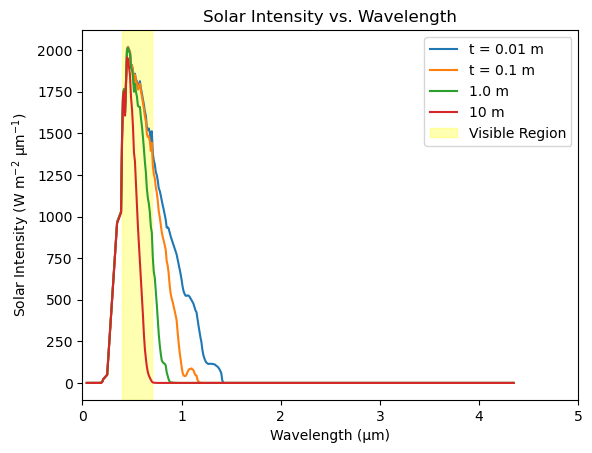

In [452]:
# Convert x and y axes
x_microns = sun_array_resized[:, 0] * 1e6  # Convert wavelength from meters to microns
y_adjusted = sun_array_resized[:, 1] / 1e6  # Adjust solar intensity to W/m^2 per micron

plt.plot(x_microns, intensity_00_1 / 1e6, label = 't = 0.01 m')
plt.plot(x_microns, intensity_0_1 / 1e6, label = 't = 0.1 m')
plt.plot(x_microns, intensity_1 / 1e6, label = '1.0 m')
plt.plot(x_microns, intensity_10 / 1e6, label = '10 m')
# plt.plot(x_microns, intensity_100 / 1e6, label = '100 m')
# plt.plot(x_microns, intensity_1000 / 1e6, label = '1000 m')

plt.axvspan(0.4, 0.7, color='yellow', alpha=0.3, label='Visible Region')

plt.xlim(0, 5)
plt.xlabel('Wavelength (µm)')
plt.ylabel(r'Solar Intensity (W m$^{-2}$ µm$^{-1}$)')
plt.title('Solar Intensity vs. Wavelength')
plt.legend()
plt.show()

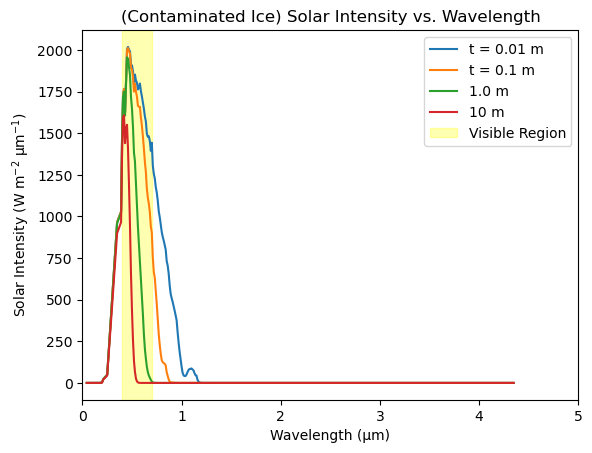

In [454]:
# Convert x and y axes
x_microns = sun_array_resized[:, 0] * 1e6  # Convert wavelength from meters to microns
y_adjusted = sun_array_resized[:, 1] / 1e6  # Adjust solar intensity to W/m^2 per micron

plt.plot(x_microns, intensity_00_1_contam / 1e6, label = 't = 0.01 m')
plt.plot(x_microns, intensity_0_1_contam / 1e6, label = 't = 0.1 m')
plt.plot(x_microns, intensity_1_contam / 1e6, label = '1.0 m')
plt.plot(x_microns, intensity_10_contam / 1e6, label = '10 m')
# plt.plot(x_microns, intensity_100 / 1e6, label = '100 m')
# plt.plot(x_microns, intensity_1000 / 1e6, label = '1000 m')

plt.axvspan(0.4, 0.7, color='yellow', alpha=0.3, label='Visible Region')

plt.xlim(0, 5)
plt.xlabel('Wavelength (µm)')
plt.ylabel(r'Solar Intensity (W m$^{-2}$ µm$^{-1}$)')
plt.title('(Contaminated Ice) Solar Intensity vs. Wavelength')
plt.legend()
plt.show()

In [456]:
# Calculating the integrated value of solar intensity (W m^-2)

# Compute the area under each curve using the trapezoidal rule
area_00_1 = np.trapz(intensity_00_1, sun_array_resized[:, 0])
area_0_1 = np.trapz(intensity_0_1, sun_array_resized[:, 0])
area_1 = np.trapz(intensity_1, sun_array_resized[:, 0])
area_10 = np.trapz(intensity_10, sun_array_resized[:, 0])
area_100 = np.trapz(intensity_100, sun_array_resized[:, 0])
area_1000 = np.trapz(intensity_1000, sun_array_resized[:, 0])

# Print the results
print(f"Area under the curve (flux) for t = 0.01 m: {area_00_1} W m²")
print(f"Area under the curve (flux) for t = 0.1 m: {area_0_1} W m²")
print(f"Area under the curve (flux) for t = 1.0 m: {area_1} W m²")
print(f"Area under the curve (flux) for t = 10 m: {area_10} W m²")
print(f"Area under the curve (flux) for t = 100 m: {area_100} W m²")
print(f"Area under the curve (flux) for t = 1000 m: {area_1000} W m²")

Area under the curve (flux) for t = 0.01 m: 1045.0170818370138 W m²
Area under the curve (flux) for t = 0.1 m: 855.0707448155779 W m²
Area under the curve (flux) for t = 1.0 m: 635.0012759851013 W m²
Area under the curve (flux) for t = 10 m: 405.2540864894131 W m²
Area under the curve (flux) for t = 100 m: 232.54859230233055 W m²
Area under the curve (flux) for t = 1000 m: 78.29134176118434 W m²


In [458]:
# Calculating the integrated value of solar intensity (W m^-2)

# Compute the area under each curve using the trapezoidal rule
area_00_1_contam = np.trapz(intensity_00_1_contam, sun_array_resized[:, 0])
area_0_1_contam = np.trapz(intensity_0_1_contam, sun_array_resized[:, 0])
area_1_contam = np.trapz(intensity_1_contam, sun_array_resized[:, 0])
area_10_contam = np.trapz(intensity_10_contam, sun_array_resized[:, 0])
area_100_contam = np.trapz(intensity_100_contam, sun_array_resized[:, 0])
area_1000_contam = np.trapz(intensity_1000_contam, sun_array_resized[:, 0])

# Print the results
print(f"Area under the curve (flux) for t = 0.01 m: {area_00_1_contam} W m²")
print(f"Area under the curve (flux) for t = 0.1 m: {area_0_1_contam} W m²")
print(f"Area under the curve (flux) for t = 1.0 m: {area_1_contam} W m²")
print(f"Area under the curve (flux) for t = 10 m: {area_10_contam} W m²")
print(f"Area under the curve (flux) for t = 100 m: {area_100_contam} W m²")
print(f"Area under the curve (flux) for t = 1000 m: {area_1000_contam} W m²")

Area under the curve (flux) for t = 0.01 m: 855.0707448155779 W m²
Area under the curve (flux) for t = 0.1 m: 635.0012759851013 W m²
Area under the curve (flux) for t = 1.0 m: 405.2540864894131 W m²
Area under the curve (flux) for t = 10 m: 232.54859230233055 W m²
Area under the curve (flux) for t = 100 m: 78.29134176118433 W m²
Area under the curve (flux) for t = 1000 m: 0.09510277924015446 W m²


## Contour plot- F(z, λ) ##
$$
F(z) = F_0 e^\frac{-z k_a}{\cos\theta}
$$

In [276]:
z = np.linspace(0, 500, 100000) # Depth values 25,000

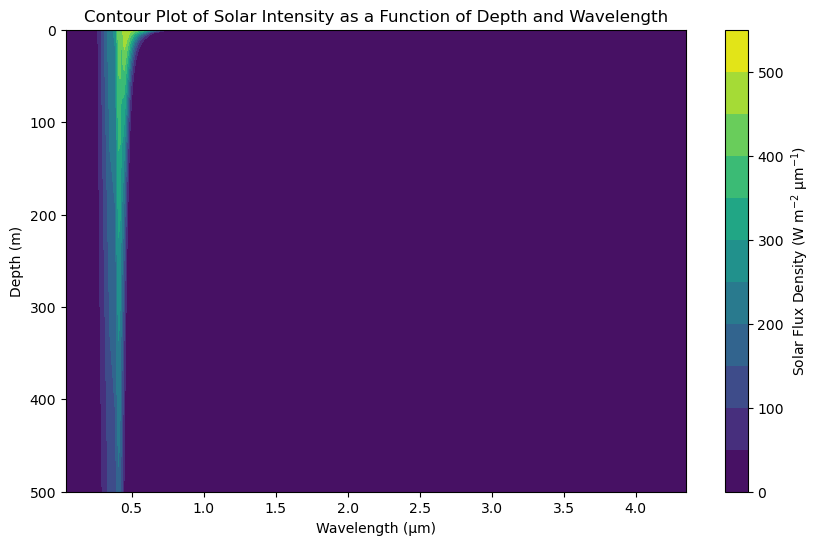

In [278]:
# Explicitly plotting solar intensity on the colorbar

wavelength = sun_ice_m*10**6  # Convert wavelength from m to microns
#wavelength = sun_array_resized[:, 0]*10**6

theta = np.pi / 3  # Incident angle of 60 degrees at mid-latitudes
theta_equ = np.pi/4 # Angle of 45 degrees at equator

# Parameters
k_values = k_abs_m_mask # k values masked for visible wavelength range in meters

irradiance = np.zeros((len(wavelength), len(z))) # initialize array of zeroes
irradiance_equ = np.zeros((len(wavelength), len(z))) # Intialize array of zeroes

for i, λ in enumerate(wavelength):    # Iterate over wavelengths
    for j, depth in enumerate(z):     # Iterate over depths
        irradiance[i,j] = ((sun_array_resized[i, 1] * np.e**(-k_values[i]*depth/np.cos(theta)))/10**6)/4 # Divide by 4 for mid-latitudes
        irradiance_equ[i,j] = ((sun_array_resized[i, 1] * np.e**(-k_values[i]*depth/np.cos(theta_equ)))/10**6)/2 # Divide by 2 for equator

# Contour plot
plt.figure(figsize=(10, 6))
contour = plt.contourf(wavelength, z, irradiance.T, levels=10, cmap='viridis')  
plt.colorbar(contour, label='Solar Flux Density (W m$^{-2}$ µm$^{-1}$)')

# Axis labels and title
plt.xlabel('Wavelength (µm)')
plt.ylabel('Depth (m)')
plt.gca().invert_yaxis()
plt.title('Contour Plot of Solar Irradiance as a Function of Depth and Wavelength')
plt.show()

In [286]:
# Sanity check

target_depth = 0  # meters (depth must be 0-10 m)

depth_index = np.argmin(np.abs(z - target_depth)) # Finds the index closest to the target depth

intensity_at_depth = irradiance[:, depth_index] # Extract intensity at that depth

solar_flux_at_depth = trapezoid(intensity_at_depth, wavelength) # Integrate over the wavelength range to get total solar flux

print(f"Solar flux at depth {target_depth} m: {solar_flux_at_depth:} W/m²")

Solar flux at depth 0 m: 339.4292452794325 W/m²


## Visible Light PAR ##

In [323]:
irradiance.shape

(315, 100000)

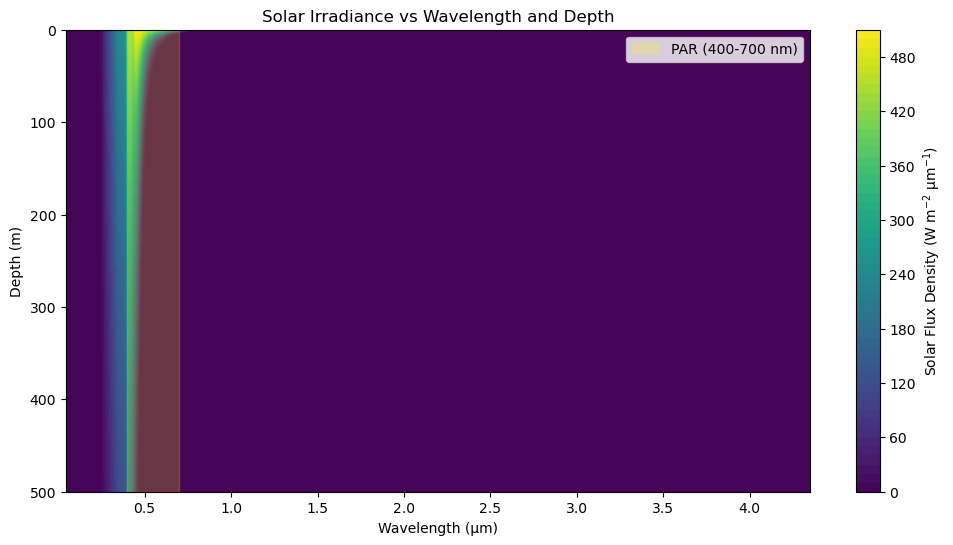

In [327]:
wavelength_nm = wavelength * 1e3  # Convert µm → nm
par_mask = (wavelength_nm >= 400) & (wavelength_nm <= 700)

wavelength_par = wavelength_nm[par_mask]
irradiance_par = irradiance[par_mask, :]

z_vis = np.linspace(0, 500, irradiance.shape[1])  # resample depth to match irradiance

plt.figure(figsize=(12, 6))
contour = plt.contourf(wavelength, z_vis, irradiance.T, levels=50, cmap='viridis')
cbar = plt.colorbar(contour, label='Solar Flux Density (W m$^{-2}$ µm$^{-1}$)')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Depth (m)')
plt.gca().invert_yaxis()
plt.title('Solar Irradiance vs Wavelength and Depth')

plt.axvspan(0.4, 0.7, color='yellow', alpha=0.2, label='PAR (400-700 nm)')

plt.legend()
plt.show()

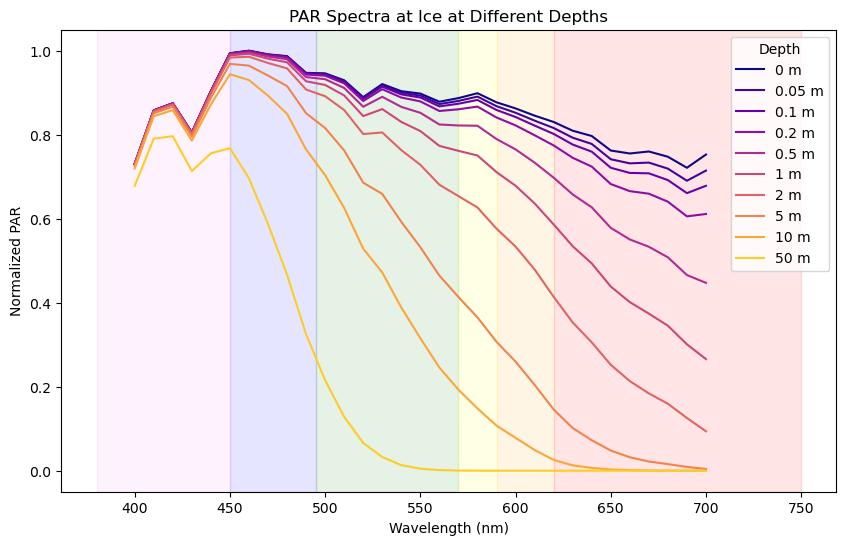

In [359]:
irradiance_par_norm = (irradiance_par-irradiance_par.min())/(irradiance_par.max()-irradiance_par.min())

depths_to_plot = [0, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 50] 
cmap = plt.get_cmap('plasma')  # color changes with depth

plt.figure(figsize=(10, 6))
for idx, depth_val in enumerate(depths_to_plot):
    depth_index = np.argmin(np.abs(z - depth_val))
    spectrum = irradiance_par_norm[:, depth_index]
    plt.plot(wavelength_par, spectrum, color=cmap(idx/len(depths_to_plot)), label=f"{depth_val} m")

plt.axvspan(380, 450, color='violet', alpha=0.1)
plt.axvspan(450, 495, color='blue', alpha=0.1)
plt.axvspan(495, 570, color='green', alpha=0.1)
plt.axvspan(570, 590, color='yellow', alpha=0.1)
plt.axvspan(590, 620, color='orange', alpha=0.1)
plt.axvspan(620, 750, color='red', alpha=0.1)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized PAR")
plt.title("PAR Spectra at Ice at Different Depths")
plt.legend(title="Depth")
plt.show()

## Interpolating Convection Coefficients ## 
Data obtained from https://www.engineeringtoolbox.com/

In [93]:
temp_c_kv = np.array([
    -75, -50, -25, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30,
    40, 50, 60, 80, 100, 125, 150, 175, 200, 225, 300,
    412, 500, 600, 700, 800, 900, 1000, 1100
])

kin_visc = np.array([
    7.4, 9.22, 11.18, 12.01, 12.43, 12.85, 13.28, 13.72,
    14.16, 14.61, 15.06, 15.52, 15.98, 16.92, 17.88, 18.86,
    20.88, 22.97, 25.69, 28.51, 31.44, 34.47, 37.6, 47.54,
    63.82, 77.72, 94.62, 112.6, 131.7, 151.7, 172.7, 194.6
])*10**-6

temp_c_diff = np.array([
    -100, -50, -30, -20, -10, -5, 0, 5, 10, 20,
    25, 30, 50, 75, 100, 125, 150, 175, 200, 250, 300
])

therm_diff = np.array([
    7.88, 13.02, 15.33, 16.54, 17.78, 18.41, 19.06, 19.71,
    20.36, 21.7, 22.39, 23.07, 25.91, 29.61, 33.49, 37.53,
    41.73, 46.07, 50.56, 59.93, 69.79
])*10**-6

temp_c_cond = np.array([
    -190, -150, -100, -75, -50, -25, -15, -10, -5, 0, 5, 10,
    15, 20, 25, 30, 40, 50, 60, 80, 100, 125, 150, 175,
    200, 225, 300, 412, 500, 600, 700, 800, 900, 1000, 1100
])

therm_cond = np.array([
    7.82, 11.69, 16.2, 18.34, 20.41, 22.41, 23.2, 23.59, 23.97,
    24.36, 24.74, 25.12, 25.5, 25.87, 26.24, 26.62, 27.35,
    28.08, 28.8, 30.23, 31.62, 33.33, 35.0, 36.64, 38.25,
    39.83, 44.41, 50.92, 55.79, 61.14, 66.32, 71.35, 76.26,
    81.08, 85.83
])*10**-3

kin_visc_interp = interp1d(temp_c_kv, kin_visc, kind='cubic', fill_value="extrapolate")
therm_diff_interp = interp1d(temp_c_diff, therm_diff, kind='cubic', fill_value="extrapolate")
therm_cond_interp = interp1d(temp_c_cond, therm_cond, kind='cubic', fill_value="extrapolate")

## Earth Ice Temperature/Surface Temperature Profiles ##

In [96]:
alpha = 1.15 * 10**-6 # m^2/s, thermal diffusivity for ice
rho = 917 # kg/m^3, density of ice
c_p = 2090 # J/kg*K, specific heat capacity of ice
k = alpha*rho*c_p # W/m*K, thermal conductivity of ice

sigma = 5.67 * 10**-8 # W/m^2K^4, Stefan-Boltzmann constant
a_e = 0.3 # albedo
A_e = 1 - a_e
d_e = 1 # for Earth, in AU

f_o_e = trapezoid(sun_array_resized[:,1]/(4*d_e**2), wavelength/10**6) 

t_o_e = (A_e*f_o_e/sigma)**(1/4)
print(f"Equilibrium Surface Temperature on Earth: {t_o_e:.2f} K") # Earth's surface temperature
print(f"Equilibrium Surface Flux on Earth: {f_o_e:.2f}  W/m²") # Earth's surface flux

Equilibrium Surface Temperature on Earth: 254.43 K
Equilibrium Surface Flux on Earth: 339.43  W/m²


In [98]:
z = np.linspace(0, 1, 50) # Depth values, grid size of 0.02 m (delta z)
target_depths_e = [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

T_at_target_depth = t_o_e
t_array_earth = [t_o_e]
t_surf_est_list = [t_o_e]

flux_vs_depth = np.array([
    trapezoid(irradiance[:, i], wavelength) for i in range(len(z))]) # Integrate across all wavelengths for every depth

for i in range(1, len(target_depths_e)):
    z0 = target_depths_e[i-1]
    z1 = target_depths_e[i]

    depth_index_1 = np.argmin(np.abs(z-z1)) # Find closest index to depth in z-array
    irradiance_1 = irradiance[:, depth_index_1] # Gives solar irradiance at depth 
    flux_1 = trapezoid(irradiance_1, wavelength) # Gives solar flux at depth

    mask = (z >= z0) & (z <= z1) # Create mask for depth region
    z_layer = z[mask] # Depth between z0 and z1
    flux_layer = flux_vs_depth[mask] # Get flux for just desired wavelength range

    absorbed_energy = trapezoid(flux_layer, z_layer) # Integrate flux over this layer (F * delta_z)
    
    delta_T = (1 / k) * absorbed_energy # Energy absorbed in this layer
    T_at_target_depth += delta_T

    T_surf_estimated = ((flux_1 / sigma) + T_at_target_depth**4)**0.25

    t_array_earth.append(T_at_target_depth)
    t_surf_est_list.append(T_surf_estimated)

    print(f"Ice temperature and solar flux at ice depth {z1} m: {T_at_target_depth:} K and flux {flux_1} Wm^-2.")

Ice temperature and solar flux at ice depth 0.05 m: 259.5699567448895 K and flux 248.5426036476723 Wm^-2.
Ice temperature and solar flux at ice depth 0.1 m: 261.76877162029007 K and flux 229.59364494890852 Wm^-2.
Ice temperature and solar flux at ice depth 0.2 m: 270.00339814820273 K and flux 213.7674556245563 Wm^-2.
Ice temperature and solar flux at ice depth 0.3 m: 277.77026912068493 K and flux 204.47353134388837 Wm^-2.
Ice temperature and solar flux at ice depth 0.4 m: 285.24016055170364 K and flux 197.9122085094161 Wm^-2.
Ice temperature and solar flux at ice depth 0.5 m: 292.49076355728727 K and flux 193.7197033583217 Wm^-2.
Ice temperature and solar flux at ice depth 0.6 m: 299.5652235972823 K and flux 189.30770545773873 Wm^-2.
Ice temperature and solar flux at ice depth 0.7 m: 306.49131668412195 K and flux 185.53991023933398 Wm^-2.
Ice temperature and solar flux at ice depth 0.8 m: 313.288792046696 K and flux 182.2444873366923 Wm^-2.
Ice temperature and solar flux at ice depth 0

In [100]:
t_surf_lim = ((A_e*4*f_o_e)/(2*sigma))**0.25   #f_o_e*4 because f_o_e is the incident solar flux divided by 4
print(t_surf_lim) # Double check surface temperature

t_surf_est_list # Inspect values for surface temperature before convection is added to the model (in K)

302.56839312093587


[254.4286771444716,
 307.3467025203254,
 305.79874279087636,
 308.7302336039964,
 312.6848934854215,
 317.0960385284233,
 321.8887347123693,
 326.69997530801095,
 331.6381849326339,
 336.670740557229,
 341.7753710453203,
 346.93573136329707]

In [102]:
# Prepare coefficients for convection addition into 1D model

t_film_earth = [] # Calculate film temp (avg temp) between T_surf and t_h at bottom of ice for convection
beta_list_earth = [] #thermal expansion coefficient, K^-1

for i in range(0, len(target_depths_e)):
    t_surf = t_surf_est_list[i]
    t_ice_h = t_array_earth[i]
    t_avg = (t_surf+t_ice_h)/2
    t_film_earth.append(t_avg)
    beta = 1/t_avg
    beta_list_earth.append(beta)

t_film_cels_earth = [(temp-273.15) for temp in t_film_earth]

nu_list_earth = []
alpha_list_earth = []
k_list_earth = []

for temp in t_film_cels_earth:
    nu = kin_visc_interp(temp)
    alpha = therm_diff_interp(temp)
    k_con = therm_cond_interp(temp)

    nu_list_earth.append(nu)
    alpha_list_earth.append(alpha)
    k_list_earth.append(k_con)

In [104]:
# Finds solution to transcendental equation for temperature
def root_fun(x, h, t_h, flux_1):
    a = sigma
    b = h # h is heat exchange coefficient, need to solve for this

    c = (-sigma*t_h**4-flux_1-h*t_h)
    return a*x**4 + b*x + c

In [106]:
# Set hyperparameters
g = 9.81 # m/s^2

t_conv_list = [[t_o_e]]
t_h = t_o_e
h_list_earth = []

for i in range(1, len(target_depths_e)):

    C = 0.54
    n = 0.25

    z0 = target_depths_e[i-1]
    z1 = target_depths_e[i]

    depth_index_1 = np.argmin(np.abs(z - z1))
    intensity_1 = irradiance[:, depth_index_1]
    flux_1 = trapezoid(intensity_1, wavelength)

    mask = (z >= z0) & (z <= z1)
    z_layer = z[mask]
    flux_layer = flux_vs_depth[mask]

    absorbed_energy = trapezoid(flux_layer, z_layer)
    delta_T_h = (1 / k) * absorbed_energy
    t_h += delta_T_h

    delta_T = t_surf_est_list[i]-t_array_earth[i]
    beta = beta_list_earth[i]
    l = 3 # characteristics length, assuming 3m height between ice and surface (according to Ansys simulation)
    nu = nu_list_earth[i]
    alpha = alpha_list_earth[i]

    Ra = (g*beta*delta_T*l**3)/(nu*alpha)
    #print(f'Rayleigh Number for {l} m: {Ra}')
        
    if Ra > 10**7 and Ra < 10**11.5: # Assuming C and n for Ra>11 and Ra<11.5 (approximation)
        C = 0.15
        n = 1/3

    # if Ra > 10**11:
    #     C = 0.10
    #     n = 1/3
        
    Nu = C*Ra**n
    
    k_cond = k_list_earth[i]
    h = (Nu*k_cond)/l
    h_list_earth.append(h)

    guess = t_o_e
    sol = optimize.root(root_fun, guess, args=(h, t_h, flux_1), method='hybr')
    t_conv_list.append(sol.x)
    
    print(f"Temperature with convection term at {z1} m: {sol.x} K and h of {h} W/m^2 K and flux of {flux_1} W/m^2 K")

Temperature with convection term at 0.05 m: [281.67303742] K and h of 6.742205420207685 W/m^2 K and flux of 248.5426036476723 W/m^2 K
Temperature with convection term at 0.1 m: [282.3956268] K and h of 6.556065765247953 W/m^2 K and flux of 229.59364494890852 W/m^2 K
Temperature with convection term at 0.2 m: [289.15714811] K and h of 6.198432803539201 W/m^2 K and flux of 213.7674556245563 W/m^2 K
Temperature with convection term at 0.3 m: [295.92595499] K and h of 5.903847876023581 W/m^2 K and flux of 204.47353134388837 W/m^2 K
Temperature with convection term at 0.4 m: [302.58148234] K and h of 5.64950052268084 W/m^2 K and flux of 197.9122085094161 W/m^2 K
Temperature with convection term at 0.5 m: [309.17975032] K and h of 5.427996004499298 W/m^2 K and flux of 193.7197033583217 W/m^2 K
Temperature with convection term at 0.6 m: [315.58347582] K and h of 5.214543105526822 W/m^2 K and flux of 189.30770545773873 W/m^2 K
Temperature with convection term at 0.7 m: [321.88020753] K and h o

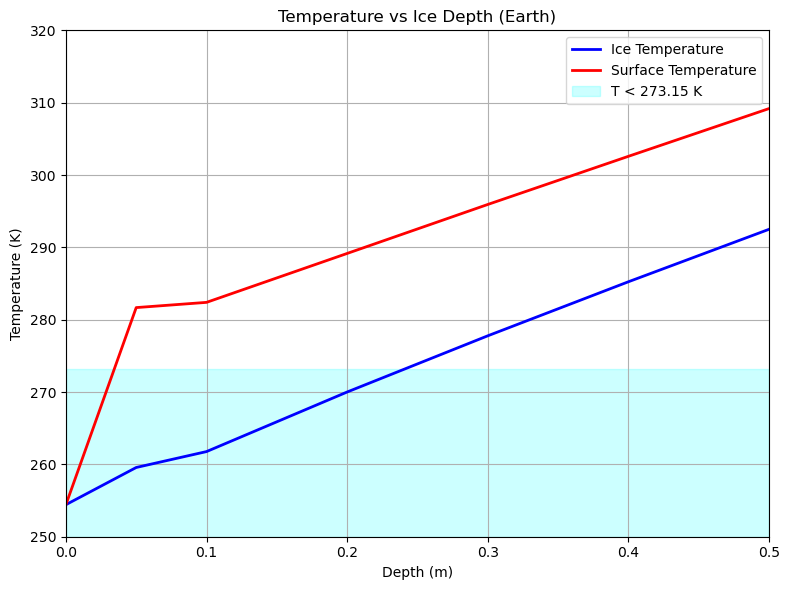

In [108]:
plt.figure(figsize=(8, 6))
plt.plot(target_depths_e, t_array_earth, label='Ice Temperature', color='blue', linewidth=2)
plt.plot(target_depths_e, t_conv_list, label='Surface Temperature', color='red', linewidth=2)

plt.xlabel("Depth (m)")
plt.ylabel("Temperature (K)")
plt.ylim(bottom=250, top=320)
plt.xlim([0,0.5])

ymin, ymax = plt.ylim()
plt.axhspan(ymin, 273.15, color='cyan', alpha=0.2, label='T < 273.15 K')
plt.title("Temperature vs Ice Depth (Earth)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [110]:
depths_cm_e = np.array(target_depths_e) * 100  # Convert to cm

t_ice_array = np.array(t_array_earth)

ice_interp = interp1d(depths_cm_e, t_ice_array, kind='linear', bounds_error=False)

for depth in range(0, 1000,1):
    val = ice_interp(depth)
    if val > 273.15:
        break

print(f"First depth where ice temp > 273.15 K: {depth} cm, temp: {val:.2f} K")

First depth where ice temp > 273.15 K: 25 cm, temp: 273.89 K


## Mars Ice Temperature/Surface Temperature Profiles ##

In [113]:
a_m = 0.17 
A_m = 1 - a_m
d_m = 1.52 

f_o_m = trapezoid(sun_array_resized[:,1]/(4*d_m**2), wavelength/10**6)

t_o_m = (A_m*f_o_m/sigma)**(1/4)
print(f"Surface Temperature on Mars: {t_o_m: .2f} K") # Moon's surface temperature
print(f"Surface Flux on Mars: {f_o_m: .2f}  W/m²") # Moon's surface flux

Surface Temperature on Mars:  215.35 K
Surface Flux on Mars:  146.91  W/m²


In [115]:
z_m = np.linspace(0, 2, 100) # 0.02 grid size (delta z)
target_depths_m = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2]

T_at_target_depth = t_o_m
t_array_mars = [t_o_m]
t_surf_est_list_mars = [t_o_m]

flux_vs_depth_mars = np.array([
    trapezoid(irradiance[:, i], wavelength) for i in range(len(z_m))])/d_m**2

for i in range(1, len(target_depths_m)):
    z0 = target_depths_m[i-1]
    z1 = target_depths_m[i]

    depth_index_1 = np.argmin(np.abs(z_m-z1)) # Find closest index to depth in z-array
    irradiance_1 = irradiance[:, depth_index_1]/d_m**2 # Gives solar irradiance at depth 
    flux_1 = trapezoid(irradiance_1, wavelength) # Gives solar flux at depth

    mask = (z_m >= z0) & (z_m <= z1) # Create mask for depth region
    z_layer = z_m[mask] # Depth between z0 and z1
    flux_layer = flux_vs_depth_mars[mask] # Get flux for desired wavelength range

    absorbed_energy = trapezoid(flux_layer, z_layer) # Integrate flux over this layer (F * delta_z)
    
    delta_T = (1 / k) * absorbed_energy # Energy absorbed in this layer
    T_at_target_depth += delta_T

    T_surf_estimated = ((flux_1 / sigma) + T_at_target_depth**4)**0.25

    t_array_mars.append(T_at_target_depth)
    t_surf_est_list_mars.append(T_surf_estimated)

    print(f"Ice temperature and solar flux at ice depth {z1} m: {T_at_target_depth:} K and {flux_1} Wm^-2.")

Ice temperature and solar flux at ice depth 0.1 m: 219.46214817933313 K and 99.37398067386968 Wm^-2.
Ice temperature and solar flux at ice depth 0.2 m: 222.99030282016423 K and 92.52400260758151 Wm^-2.
Ice temperature and solar flux at ice depth 0.3 m: 226.31804595136919 K and 88.50135532543645 Wm^-2.
Ice temperature and solar flux at ice depth 0.4 m: 229.51854715558514 K and 85.66144758890934 Wm^-2.
Ice temperature and solar flux at ice depth 0.5 m: 232.62509346418358 K and 83.43746213645657 Wm^-2.
Ice temperature and solar flux at ice depth 0.6 m: 235.65617070088365 K and 81.59168064618997 Wm^-2.
Ice temperature and solar flux at ice depth 0.7 m: 238.62367959571094 K and 80.00655430769919 Wm^-2.
Ice temperature and solar flux at ice depth 0.8 m: 241.53608177510642 K and 78.6149127120067 Wm^-2.
Ice temperature and solar flux at ice depth 0.9 m: 244.39978484154884 K and 77.37385554161793 Wm^-2.
Ice temperature and solar flux at ice depth 1.0 m: 247.2198423682133 K and 76.46924098167342

In [117]:
# print(t_surf_lim_m) # Double check surface temperature

t_surf_est_list_mars # Inspect values for surface temperature before convection is added to the model 

[215.34722463987006,
 252.61644921233628,
 253.1111984217278,
 254.335424083746,
 255.86382492910516,
 257.54996490937515,
 259.3325084137259,
 261.1810144475044,
 263.0779409798406,
 265.01196130863116,
 267.0250768832461,
 292.57140199357343]

In [119]:
# Prepare coefficients for convection addition into 1D model

t_film_mars = [] # Calculate film temp (avg temp) between T_surf and t_h at bottom of ice
beta_list_mars = [] #thermal expansion coefficient, K^-1

for i in range(0, len(target_depths_m)):
    t_surf = t_surf_est_list_mars[i]
    t_ice_h = t_array_mars[i]
    t_avg = (t_surf+t_ice_h)/2
    t_film_mars.append(t_avg)
    beta = 1/t_avg
    beta_list_mars.append(beta)

nu_list_mars = []
alpha_list_mars = []
k_list_mars = []

t_film_cels_mars = [(temp-273.15) for temp in t_film_mars]

for temp in t_film_cels_mars:
    nu = kin_visc_interp(temp)
    alpha = therm_diff_interp(temp)
    k_con = therm_cond_interp(temp)

    nu_list_mars.append(nu)
    alpha_list_mars.append(alpha)
    k_list_mars.append(k_con)

In [121]:
k_list_mars

[array(0.01977207),
 array(0.02144754),
 array(0.02160802),
 array(0.02178925),
 array(0.02197718),
 array(0.02216734),
 array(0.02235808),
 array(0.02254871),
 array(0.02273888),
 array(0.02292837),
 array(0.02311902),
 array(0.0253447)]

In [123]:
target_depths_m = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2]

g_m = 3.73 #m/s^2

t_conv_list_mars = [[t_o_m]]
h_list_mars = []

t_h = t_o_m

for i in range(1, len(target_depths_m)):
    
    C = 0.54 # For 10^4<Ra<10^7
    n = 0.25 # For 10^4<Ra<10^7

    z0 = target_depths_m[i-1]
    z1 = target_depths_m[i]

    depth_index_1 = np.argmin(np.abs(z_m - z1))
    intensity_1 = irradiance[:, depth_index_1]/d_m**2
    flux_1 = trapezoid(intensity_1, wavelength)

    mask = (z_m >= z0) & (z_m <= z1)
    z_layer = z_m[mask]
    flux_layer = flux_vs_depth_mars[mask]

    absorbed_energy = trapezoid(flux_layer, z_layer)
    delta_T_h = (1 / k) * absorbed_energy
    t_h += delta_T_h

    delta_T = t_surf_est_list_mars[i] - t_array_mars[i]
    beta = beta_list_mars[i]
    l = 8/3
    nu = nu_list_mars[i]
    alpha = alpha_list_mars[i]

    Ra = (g_m*beta*delta_T*l**3)/(nu*alpha)

    if Ra > 10**7 and Ra < 10**11:
        C = 0.15
        n = 1/3
    
    Nu = C*Ra**n

    k_cond = k_list_mars[i]
    h = (Nu*k_cond)/l
    h_list_mars.append(h)
    
    guess = t_o_m
    sol = optimize.root(root_fun, guess, args = (h, t_h, flux_1), method = 'hybr')
    t_conv_list_mars.append(sol.x)
    
    print(f"Temperature with convection term at {z1} m: {sol.x} K and h of {h} W/m^2 K and flux of {flux_1} W/m^2 K")

Temperature with convection term at 0.1 m: [232.66633675] K and h of 4.903483457592173 W/m^2 K and flux of 99.37398067386968 W/m^2 K
Temperature with convection term at 0.2 m: [235.40296071] K and h of 4.721341103682809 W/m^2 K and flux of 92.52400260758151 W/m^2 K
Temperature with convection term at 0.3 m: [238.24101923] K and h of 4.578547551102879 W/m^2 K and flux of 88.50135532543645 W/m^2 K
Temperature with convection term at 0.4 m: [241.07616794] K and h of 4.455333706252685 W/m^2 K and flux of 85.66144758890934 W/m^2 K
Temperature with convection term at 0.5 m: [243.88035016] K and h of 4.344185190556252 W/m^2 K and flux of 83.43746213645657 W/m^2 K
Temperature with convection term at 0.6 m: [246.64649485] K and h of 4.241682304090646 W/m^2 K and flux of 81.59168064618997 W/m^2 K
Temperature with convection term at 0.7 m: [249.3740445] K and h of 4.145990141678997 W/m^2 K and flux of 80.00655430769919 W/m^2 K
Temperature with convection term at 0.8 m: [252.06446972] K and h of 4

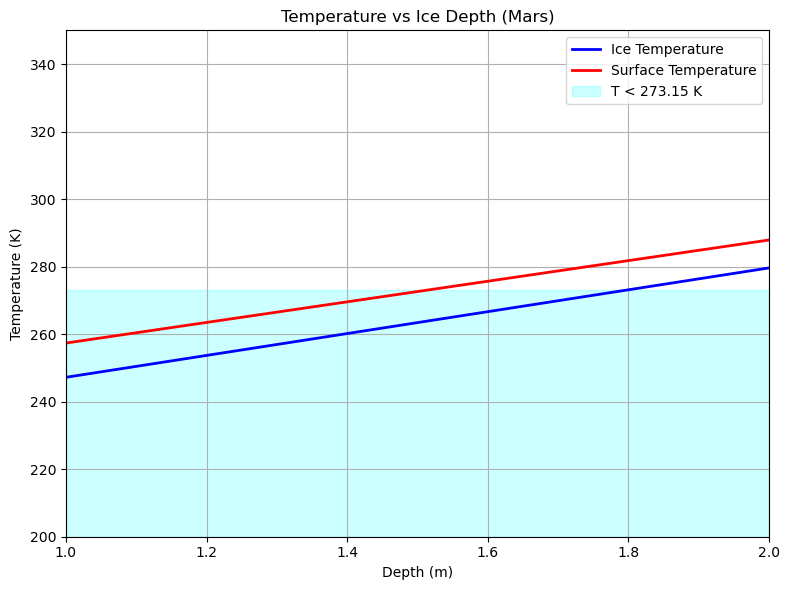

In [125]:
plt.figure(figsize=(8, 6))
plt.plot(target_depths_m, t_array_mars, label='Ice Temperature', color='blue', linewidth=2)
plt.plot(target_depths_m, t_conv_list_mars, label='Surface Temperature', color='red', linewidth=2)
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (K)")

plt.ylim(bottom=200, top=350)

ymin, ymax = plt.ylim()
plt.axhspan(ymin, 273.15, color='cyan', alpha=0.2, label='T < 273.15 K')

plt.xlim([1,2])
plt.title("Temperature vs Ice Depth (Mars)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [127]:
depths_cm_m = np.array(target_depths_m) * 100  # Convert to cm

t_ice_array = np.array(t_array_mars)

ice_interp = interp1d(depths_cm_m, t_ice_array, kind='linear', bounds_error=False)

for depth in range(0, 5000,1):
    val = ice_interp(depth)
    if val > 273.15:
        break

print(f"First depth where ice temp > 273.15 K: {depth} cm, temp: {val:.2f} K")

First depth where ice temp > 273.15 K: 181 cm, temp: 273.46 K


## Ceres Mid-Latitudes/Equator Ice/Surface Temperature Profile ## 

In [130]:
a_ce = 0.07 # albedo
A_ce = 1 - a_ce
d_ce = 2.77 # for Earth, in AU

f_o_ce = trapezoid(sun_array_resized[:,1]/(4*d_ce**2), wavelength/10**6)
f_o_equ_ce = trapezoid(sun_array_resized[:,1]/(2*d_ce**2), wavelength/10**6)

t_o_ce = (A_ce*f_o_ce/sigma)**(1/4)
t_o_equ_ce = (A_ce*f_o_equ_ce/sigma)**(1/4)

print(f"Surface Temperature on Ceres Mid-Latitudes: {t_o_ce:.2f} K")
print(f"Surface Flux on Ceres Mid-Latitudes: {f_o_ce:.2f}  W/m²")

print(f"Surface Temperature on Ceres Equator: {t_o_equ_ce:.2f} K")
print(f"Surface Flux on Ceres Equator: {f_o_equ_ce:.2f}  W/m²")

Surface Temperature on Ceres Mid-Latitudes: 164.12 K
Surface Flux on Ceres Mid-Latitudes: 44.24  W/m²
Surface Temperature on Ceres Equator: 195.18 K
Surface Flux on Ceres Equator: 88.47  W/m²


In [132]:
z_ce = np.linspace(0, 20, 1000) # 0.02 grid size
target_depths_ce = [0, 0.2, 0.5, 1.0, 2, 5, 10, 20]

t_array_ceres = [t_o_ce]
t_surf_est_list_ceres = [t_o_ce]

t_array_ceres_equ = [t_o_equ_ce]
t_surf_est_list_ceres_equ = [t_o_equ_ce]


flux_vs_depth_ceres = np.array([
    trapezoid(irradiance[:, i], wavelength) for i in range(len(z_ce))])/d_ce**2

flux_vs_depth_ceres_equ = np.array([
    trapezoid(irradiance_equ[:, i], wavelength) for i in range(len(z_ce))])/d_ce**2


T_at_target_depth_ce = t_o_ce
T_at_target_depth_ce_equ = t_o_equ_ce

for i in range(1, len(target_depths_ce)):
    z0 = target_depths_ce[i-1]
    z1 = target_depths_ce[i]

    depth_index_1 = np.argmin(np.abs(z_ce - z1))
    intensity_1 = irradiance[:, depth_index_1]/(d_ce**2)
    intensity_1_equ = irradiance_equ[:, depth_index_1]/(d_ce**2)
    
    flux_1 = trapezoid(intensity_1, wavelength)
    flux_1_equ = trapezoid(intensity_1_equ, wavelength)

    mask = (z_ce >= z0) & (z_ce <= z1)
    z_layer = z_ce[mask]
    
    flux_layer = flux_vs_depth_ceres[mask]
    flux_layer_equ = flux_vs_depth_ceres_equ[mask]

    # Integrate flux over this layer
    absorbed_energy = trapezoid(flux_layer, z_layer)
    absorbed_energy_equ = trapezoid(flux_layer_equ, z_layer)

    # Energy absorbed in this layer
    
    delta_T = (1 / k) * absorbed_energy
    delta_T_equ = (1 / k) * absorbed_energy_equ
    
    T_at_target_depth_ce += delta_T
    T_at_target_depth_ce_equ += delta_T_equ

    t_array_ceres.append(T_at_target_depth_ce)
    t_array_ceres_equ.append(T_at_target_depth_ce_equ)

    T_estimated = ((flux_1 / sigma) + T_at_target_depth_ce**4)**0.25
    T_estimated_equ = ((flux_1_equ / sigma) + T_at_target_depth_ce_equ**4)**0.25
    
    t_surf_est_list_ceres.append(T_estimated)
    t_surf_est_list_ceres_equ.append(T_estimated_equ)

    #print(flux_avg)
    print(f"Ceres Mid-Latitude Temperature at depth {z1} m: {T_at_target_depth_ce:} K and flux {flux_1} W m^-2")
    print(f"Ceres Equator Temperature at depth {z1} m: {T_at_target_depth_ce_equ:} K and flux {flux_1_equ} W m^-2\n")


Ceres Mid-Latitude Temperature at depth 0.2 m: 166.6794826251399 K and flux 27.86006016298353 W m^-2
Ceres Equator Temperature at depth 0.2 m: 200.43310575833874 K and flux 57.803052184367964 W m^-2

Ceres Mid-Latitude Temperature at depth 0.5 m: 170.03247866577698 K and flux 25.12399647070459 W m^-2
Ceres Equator Temperature at depth 0.5 m: 207.40216719751083 K and flux 52.32195285634546 W m^-2

Ceres Mid-Latitude Temperature at depth 1.0 m: 175.25775040253026 K and flux 22.96090669350468 W m^-2
Ceres Equator Temperature at depth 1.0 m: 218.3184137441399 K and flux 48.11877910173168 W m^-2

Ceres Mid-Latitude Temperature at depth 2 m: 184.92582434048947 K and flux 20.68970847370868 W m^-2
Ceres Equator Temperature at depth 2 m: 238.6577991663714 K and flux 43.66942288612847 W m^-2

Ceres Mid-Latitude Temperature at depth 5 m: 210.564167772242 K and flux 17.639123552496955 W m^-2
Ceres Equator Temperature at depth 5 m: 293.0561198382 K and flux 37.5849295718765 W m^-2

Ceres Mid-Latitu

In [134]:
print(t_surf_est_list_ceres) # Verification of both
print(t_surf_est_list_ceres_equ)

[164.12411697555848, 188.52465217941642, 189.1096101665208, 191.62549398957773, 197.91677038464258, 218.44165954509666, 251.9288460566008, 313.59531829041447]
[195.17756765087304, 226.5309274368555, 229.47884862691694, 236.34854650623296, 251.7118689340141, 299.42960177161484, 375.06074442962, 511.34325453170607]


In [136]:
t_film_ceres = [] # Calculate film temp (avg temp) between T_surf and t_h at bottom of ice
beta_list_ceres = [] #thermal expansion coefficient, K^-1

for i in range(0, len(target_depths_ce)):
    t_surf = t_surf_est_list_ceres[i]
    t_ice_h = t_array_ceres[i]
    t_avg = (t_surf+t_ice_h)/2
    t_film_ceres.append(t_avg)
    beta = 1/t_avg
    beta_list_ceres.append(beta)

t_film_cels_ceres = [(temp-273.15) for temp in t_film_ceres]

nu_list_ceres = []
alpha_list_ceres = []
k_list_ceres = []

for temp in t_film_cels_ceres:
    nu = kin_visc_interp(temp)
    alpha = therm_diff_interp(temp)
    k_con = therm_cond_interp(temp)

    nu_list_ceres.append(nu)
    alpha_list_ceres.append(alpha)
    k_list_ceres.append(k_con)

### Equator parameters for convection 

t_film_ceres_equ = [] 
beta_list_ceres_equ = [] 

for i in range(0, len(target_depths_ce)):
    t_surf = t_surf_est_list_ceres_equ[i]
    t_ice_h = t_array_ceres_equ[i]
    t_avg = (t_surf+t_ice_h)/2
    t_film_ceres_equ.append(t_avg)
    beta = 1/t_avg
    beta_list_ceres_equ.append(beta)

t_film_cels_ceres_equ = [(temp-273.15) for temp in t_film_ceres_equ]

nu_list_ceres_equ = []
alpha_list_ceres_equ = []
k_list_ceres_equ = []

for temp in t_film_cels_ceres_equ:
    nu = kin_visc_interp(temp)
    alpha = therm_diff_interp(temp)
    k_con = therm_cond_interp(temp)

    nu_list_ceres_equ.append(nu)
    alpha_list_ceres_equ.append(alpha)
    k_list_ceres_equ.append(k_con)

In [138]:
g_ce = 0.27 #m/s^2

t_conv_list_ceres = [[t_o_ce]]
t_conv_list_ceres_equ = [[t_o_equ_ce]]

t_h_ce = t_o_ce

h_list_ceres = []
h_list_equ_ceres = []

t_h_ce = t_o_ce
t_h_ce_equ = t_o_equ_ce


for i in range(1, len(target_depths_ce)):
    
    C = 0.54 # For 10^4<Ra<10^7
    n = 0.25 # For 10^4<Ra<10^7

    C_equ = 0.54 # For 10^4<Ra<10^7
    n_equ = 0.25 # For 10^4<Ra<10^7

    z0 = target_depths_ce[i-1]
    z1 = target_depths_ce[i]

    depth_index_1 = np.argmin(np.abs(z_ce - z1))

    intensity_1 = irradiance[:, depth_index_1]/d_ce**2
    intensity_1_equ = irradiance_equ[:, depth_index_1]/d_ce**2

    flux_1 = trapezoid(intensity_1, wavelength)
    flux_1_equ = trapezoid(intensity_1_equ, wavelength)

    mask = (z_ce >= z0) & (z_ce <= z1)
    z_layer = z_ce[mask]
    
    flux_layer = flux_vs_depth_ceres[mask]
    flux_layer_equ = flux_vs_depth_ceres_equ[mask]

    absorbed_energy = trapezoid(flux_layer, z_layer)
    absorbed_energy_equ = trapezoid(flux_layer_equ, z_layer)

    delta_T_h = (1 / k) * absorbed_energy
    delta_T_h_equ = (1 / k) * absorbed_energy_equ

    t_h_ce += delta_T_h
    t_h_ce_equ += delta_T_h_equ
    
    delta_T = t_surf_est_list_ceres[i]-t_array_ceres[i]
    beta = beta_list_ceres[i]
    l = 3
    nu = nu_list_ceres[i]
    alpha = alpha_list_ceres[i]

    delta_T_equ = t_surf_est_list_ceres_equ[i]-t_array_ceres_equ[i]
    beta_equ = beta_list_ceres_equ[i]
    nu_equ = nu_list_ceres_equ[i]
    alpha_equ = alpha_list_ceres_equ[i]

    Ra = (g_ce*beta*delta_T*l**3)/(nu*alpha)
    Ra_equ = (g_ce*beta_equ*delta_T_equ*l**3)/(nu_equ*alpha_equ)

    if Ra > 10**7 and Ra < 10**11:
        C = 0.15
        n = 1/3
    
    if Ra_equ > 10**7 and Ra_equ < 10**11:
        C_equ = 0.15
        n_equ = 1/3

    Nu = C*Ra**n
    Nu_equ = C_equ*Ra_equ**n_equ

    k_cond = k_list_ceres[i]
    k_cond_equ = k_list_ceres_equ[i]
    
    h = (Nu*k_cond)/l
    h_equ = (Nu_equ*k_cond_equ)/l
    
    h_list_ceres.append(h)
    h_list_equ_ceres.append(h_equ)
    
    guess = t_o_ce
    guess_equ = t_o_equ_ce

    sol = optimize.root(root_fun, guess, args = (h, t_h_ce, flux_1), method = 'hybr')
    sol_equ = optimize.root(root_fun, guess_equ, args=(h_equ, t_h_ce_equ, flux_1_equ), method = 'hybr')
        
    t_conv_list_ceres.append(sol.x)
    t_conv_list_ceres_equ.append(sol_equ.x)
    
    print(f"Ceres Mid-Latitude Temperature at {z1} m: {sol.x} K and h {h} and {flux_1} W/m^2 K")
    print(f"Ceres Mid-Latitude Temperature at {z1} m: {sol_equ.x} K and h {h_equ} and {flux_1_equ} W/m^2 K\n")

Ceres Mid-Latitude Temperature at 0.2 m: [175.09947909] K and h 2.1762597537591644 and 27.86006016298353 W/m^2 K
Ceres Mid-Latitude Temperature at 0.2 m: [214.69424745] K and h 2.0226557202509663 and 57.803052184367964 W/m^2 K

Ceres Mid-Latitude Temperature at 0.5 m: [177.74880822] K and h 2.0628281229091674 and 25.12399647070459 W/m^2 K
Ceres Mid-Latitude Temperature at 0.5 m: [220.16159117] K and h 1.8827498490240482 and 52.32195285634546 W/m^2 K

Ceres Mid-Latitude Temperature at 1.0 m: [182.3744149] K and h 1.929074918344735 and 22.96090669350468 W/m^2 K
Ceres Mid-Latitude Temperature at 1.0 m: [229.60999256] K and h 1.7119762936645637 and 48.11877910173168 W/m^2 K

Ceres Mid-Latitude Temperature at 2 m: [191.30862061] K and h 1.731213432921357 and 20.68970847370868 W/m^2 K
Ceres Mid-Latitude Temperature at 2 m: [247.89869827] K and h 1.458966173966349 and 43.66942288612847 W/m^2 K

Ceres Mid-Latitude Temperature at 5 m: [215.53866321] K and h 1.3523218377167892 and 17.63912355249

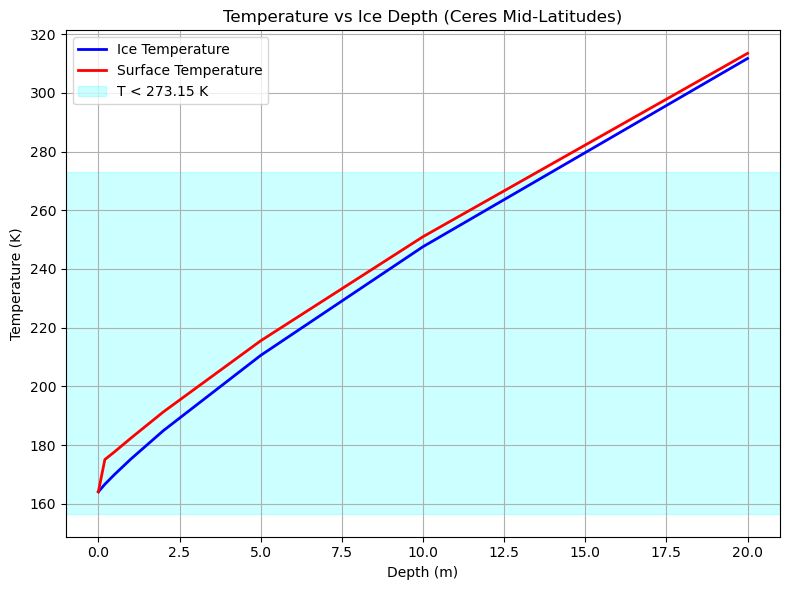

In [140]:
plt.figure(figsize=(8, 6))
plt.plot(target_depths_ce, t_array_ceres, label='Ice Temperature', color='blue', linewidth=2)
plt.plot(target_depths_ce, t_conv_list_ceres, label='Surface Temperature', color='red', linewidth=2)
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (K)")

ymin, ymax = plt.ylim()
plt.axhspan(ymin, 273.15, color='cyan', alpha=0.2, label='T < 273.15 K')

plt.title("Temperature vs Ice Depth (Ceres Mid-Latitudes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [142]:
depths_cm_ce = np.array(target_depths_ce) * 100  

t_ice_array = np.array(t_array_ceres)

ice_interp = interp1d(depths_cm_ce, t_ice_array, kind='linear', bounds_error=False)

for depth in range(0, 2000,1):
    val = ice_interp(depth)
    if val > 273.15:
        break

print(f"First depth where ice temp > 273.15 K: {depth} cm, temp: {val:.2f} K")

First depth where ice temp > 273.15 K: 1399 cm, temp: 273.16 K


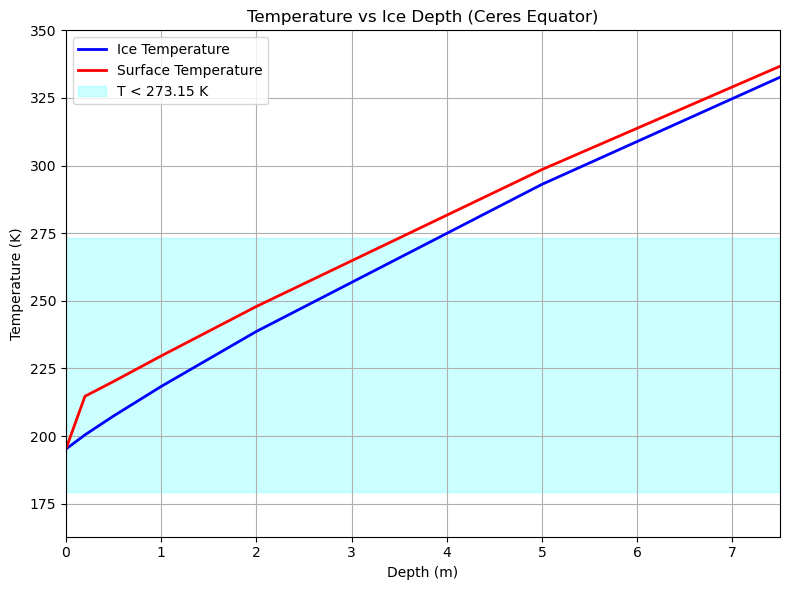

In [144]:
plt.figure(figsize=(8, 6))
plt.plot(target_depths_ce, t_array_ceres_equ, label='Ice Temperature', color='blue', linewidth=2)
plt.plot(target_depths_ce, t_conv_list_ceres_equ, label='Surface Temperature', color='red', linewidth=2)
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (K)")

ymin, ymax = plt.ylim()
plt.axhspan(ymin, 273.15, color='cyan', alpha=0.2, label='T < 273.15 K')

plt.ylim(top=350)
plt.xlim([0,7.5])
plt.title("Temperature vs Ice Depth (Ceres Equator)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [146]:
depths_cm_ce_equ = np.array(target_depths_ce) * 100 

t_ice_array_equ = np.array(t_array_ceres_equ)

ice_interp_equ = interp1d(depths_cm_ce_equ, t_ice_array_equ, kind='linear', bounds_error=False)

for depth in range(0, 2000,1):
    val = ice_interp_equ(depth)
    if val > 273.15:
        break

print(f"First depth where ice temp > 273.15 K: {depth} cm, temp: {val:.2f} K")

First depth where ice temp > 273.15 K: 391 cm, temp: 273.29 K


## Callisto Mid-Latitudes/Equator Ice/Surface Temperature Profile ##

In [474]:
a_ca = 0.2 # albedo
A_ca = 1 - a_ca
d_ca = 5.2 # for Callisto, in AU

f_o_ca = trapezoid(sun_array_resized[:,1]/(4*d_ca**2), wavelength/10**6) 
f_o_equ_ca = trapezoid(sun_array_resized[:,1]/(2*d_ca**2), wavelength/10**6) 

t_o_ca = (A_ca*f_o_ca/sigma)**(1/4)
t_o_equ_ca = (A_ca*f_o_equ_ca/sigma)**(1/4)
print(f"Mid-Latitudes Surface Temperature on Callisto: {t_o_ca:.2f} K") # Callisto's surface temperature
print(f"Surface Temperature on Callisto at the equator: {t_o_equ_ca:.2f} K") # Callisto's surface temperature
print(f"Mid-Latitudes Surface Flux on Callisto: {f_o_ca:.2f}  W/m²") # Callisto's surface flux
print(f"Surface Flux on Callisto at the equator: {f_o_equ_ca:.2f}  W/m²") # Callisto's surface flux

Mid-Latitudes Surface Temperature on Callisto: 115.36 K
Surface Temperature on Callisto at the equator: 137.19 K
Mid-Latitudes Surface Flux on Callisto: 12.55  W/m²
Surface Flux on Callisto at the equator: 25.11  W/m²


In [476]:
z_ca = np.linspace(0, 150, 7500) # Depth values, grid size of 0.02 (delta z)
target_depths_ca = [0, 0.1, 0.2, 0.5, 1.0, 2, 5, 10, 100, 150]

flux_vs_depth_callisto = np.array([
    trapezoid(irradiance[:, i], wavelength) for i in range(len(z_ca))])/d_ca**2

flux_vs_depth_callisto_equ = np.array([
    trapezoid(irradiance_equ[:, i], wavelength) for i in range(len(z_ca))])/d_ca**2


T_at_target_depth_ca = t_o_ca
T_at_target_depth_equ_ca = t_o_equ_ca

t_array_callisto = [t_o_ca]
t_array_callisto_equ = [t_o_equ_ca]

t_surf_est_list_ca = [t_o_ca]
t_surf_est_list_equ_ca = [t_o_equ_ca]

for i in range(1, len(target_depths_ca)):
    z0 = target_depths_ca[i-1]
    z1 = target_depths_ca[i]

    depth_index_1 = np.argmin(np.abs(z_ca - z1))
    
    intensity_1 = irradiance[:, depth_index_1]/d_ca**2
    intensity_1_equ = irradiance_equ[:, depth_index_1]/d_ca**2
    
    flux_1 = trapezoid(intensity_1, wavelength)
    flux_1_equ = trapezoid(intensity_1_equ, wavelength)

    mask = (z_ca >= z0) & (z_ca <= z1)
    z_layer = z_ca[mask]
    
    flux_layer = flux_vs_depth_callisto[mask]
    flux_layer_equ = flux_vs_depth_callisto_equ[mask]

    absorbed_energy = trapezoid(flux_layer, z_layer)
    absorbed_energy_equ = trapezoid(flux_layer_equ, z_layer)
    
    delta_T = (1 / k) * absorbed_energy
    delta_T_equ = (1 / k) * absorbed_energy_equ
    
    T_at_target_depth_ca += delta_T
    T_at_target_depth_equ_ca += delta_T_equ

    T_estimated = ((flux_1 / sigma) + T_at_target_depth_ca**4)**0.25
    T_estimated_equ = ((flux_1_equ / sigma) + T_at_target_depth_equ_ca**4)**0.25

    t_array_callisto.append(T_at_target_depth_ca)
    t_array_callisto_equ.append(T_at_target_depth_equ_ca)
    
    t_surf_est_list_ca.append(T_estimated)
    t_surf_est_list_equ_ca.append(T_estimated_equ)

    print(f"Mid-latitude Temperature at depth {z1} m: {T_at_target_depth_ca:.2f} K")
    print(f"Equator Temperature at depth {z1} m: {T_at_target_depth_equ_ca:.2f} K\n")

Mid-latitude Temperature at depth 0.1 m: 115.71 K
Equator Temperature at depth 0.1 m: 137.90 K

Mid-latitude Temperature at depth 0.2 m: 116.01 K
Equator Temperature at depth 0.2 m: 138.52 K

Mid-latitude Temperature at depth 0.5 m: 116.96 K
Equator Temperature at depth 0.5 m: 140.49 K

Mid-latitude Temperature at depth 1.0 m: 118.44 K
Equator Temperature at depth 1.0 m: 143.59 K

Mid-latitude Temperature at depth 2 m: 121.18 K
Equator Temperature at depth 2 m: 149.36 K

Mid-latitude Temperature at depth 5 m: 128.45 K
Equator Temperature at depth 5 m: 164.78 K

Mid-latitude Temperature at depth 10 m: 138.95 K
Equator Temperature at depth 10 m: 187.24 K

Mid-latitude Temperature at depth 100 m: 265.24 K
Equator Temperature at depth 100 m: 460.93 K

Mid-latitude Temperature at depth 150 m: 320.47 K
Equator Temperature at depth 150 m: 581.22 K



In [478]:
print(t_surf_est_list_ca) # Inspect values for surface temperature before convection is added to the model 
print(t_surf_est_list_equ_ca) # Inspect values for surface temperature before convection is added to the model 

[115.3618932534802, 134.6798769144485, 133.8050367598892, 132.99595802971743, 132.8722002765051, 133.6636127408888, 137.7937996733435, 145.61286921932984, 265.8441992153238, 320.77616412413664]
[137.18918425722308, 160.93938628976886, 160.12662326549, 159.7617732497238, 160.64022165560925, 163.58825721935503, 174.41098670169268, 193.2299773835196, 461.18162270371295, 581.3352225731416]


In [480]:
t_film_callisto = [] # Calculate film temp (avg temp) between T_surf and t_h at bottom of ice
beta_list_callisto = [] #thermal expansion coefficient, K^-1

for i in range(0, len(target_depths_ca)):
    t_surf = t_surf_est_list_ca[i]
    t_ice_h = t_array_callisto[i]
    t_avg = (t_surf+t_ice_h)/2
    t_film_callisto.append(t_avg)
    beta = 1/t_avg
    beta_list_callisto.append(beta)

t_film_cels_callisto = [(temp-273.15) for temp in t_film_callisto]

nu_list_callisto = []
alpha_list_callisto = []
k_list_callisto = []

for temp in t_film_cels_callisto:
    nu = kin_visc_interp(temp)
    alpha = therm_diff_interp(temp)
    k_con = therm_cond_interp(temp)

    nu_list_callisto.append(nu)
    alpha_list_callisto.append(alpha)
    k_list_callisto.append(k_con)

In [482]:
# Repeating the same for Callisto equator

t_film_callisto_equ = [] # Calculate film temp (avg temp) between T_surf and t_h at bottom of ice
beta_list_callisto_equ = [] #thermal expansion coefficient, K^-1

for i in range(0, len(target_depths_ca)):
    t_surf = t_surf_est_list_equ_ca[i]
    t_ice_h = t_array_callisto_equ[i]
    t_avg = (t_surf+t_ice_h)/2
    t_film_callisto_equ.append(t_avg)
    beta = 1/t_avg
    beta_list_callisto_equ.append(beta)

t_film_cels_callisto_equ = [(temp-273.15) for temp in t_film_callisto_equ]

nu_list_callisto_equ = []
alpha_list_callisto_equ = []
k_list_callisto_equ = []

for temp in t_film_cels_callisto_equ:
    nu = kin_visc_interp(temp)
    alpha = therm_diff_interp(temp)
    k_con = therm_cond_interp(temp)

    nu_list_callisto_equ.append(nu)
    alpha_list_callisto_equ.append(alpha)
    k_list_callisto_equ.append(k_con)

In [484]:
# Set hyperparameters for convection term surface temperature calculation
g_ca = 1.24 # m/s^2

t_conv_list_callisto = [[t_o_ca]]
t_h_ca = t_o_ca

t_conv_list_callisto_equ = [[t_o_equ_ca]]
t_h_equ_ca = t_o_equ_ca

for i in range(1, len(target_depths_ca)):

    C = 0.54 # For 10^4<Ra<10^7
    C_equ = 0.54 # For 10^4<Ra<10^7
    
    n = 0.25 # For 10^4<Ra<10^7
    n_equ = 0.25 # For 10^4<Ra<10^7

    z0 = target_depths_ca[i-1]
    z1 = target_depths_ca[i]

    depth_index_1 = np.argmin(np.abs(z_ca - z1))
    intensity_1 = irradiance[:, depth_index_1]/d_ca**2
    intensity_1_equ = irradiance_equ[:, depth_index_1]/d_ca**2
    
    flux_1 = trapezoid(intensity_1, wavelength)
    flux_1_equ = trapezoid(intensity_1_equ, wavelength)

    mask = (z_ca >= z0) & (z_ca <= z1)
    z_layer = z_ca[mask]
    
    flux_layer = flux_vs_depth_callisto[mask]
    flux_layer_equ = flux_vs_depth_callisto_equ[mask]

    absorbed_energy = trapezoid(flux_layer, z_layer)
    absorbed_energy_equ = trapezoid(flux_layer_equ, z_layer)
    
    delta_T_h = (1 / k) * absorbed_energy
    delta_T_h_equ = (1 / k) * absorbed_energy_equ
    
    t_h_ca += delta_T_h
    t_h_equ_ca += delta_T_h_equ
    
    delta_T = t_surf_est_list_ca[i]-t_array_callisto[i]
    delta_T_equ = t_surf_est_list_equ_ca[i]-t_array_callisto_equ[i]
    
    beta = beta_list_callisto[i]
    beta_equ = beta_list_callisto_equ[i]
    l = 3
    nu = nu_list_callisto[i]
    nu_equ = nu_list_callisto_equ[i]
    alpha = alpha_list_callisto[i]
    alpha_equ = alpha_list_callisto_equ[i]


    Ra = (g_ca*beta*delta_T*l**3)/(nu*alpha)
    Ra_equ = (g_ca*beta_equ*delta_T_equ*l**3)/(nu_equ*alpha_equ)
    #print(f'Rayleigh Number for {l} m: {Ra}')

    if Ra > 10**7 and Ra < 10**12: # Assuming same C and n for Ra>10**11 for first few values
        C = 0.15
        n = 1/3
    
    if Ra_equ > 10**7 and Ra_equ < 10**12: # Assuming same C_equ and n_equ for Ra_equ>10**11 for first few values
        C_equ = 0.15
        n_equ = 1/3
   
    Nu = C*Ra**n
    Nu_equ = C_equ*Ra_equ**n_equ
    # print(f'Nusselt Number: {Nu}')

    k_cond = k_list_callisto[i]
    k_cond_equ = k_list_callisto_equ[i]
    h = (Nu*k_cond)/l
    h_equ = (Nu_equ*k_cond_equ)/l
    # print(f'Exchange Coefficient h: {h} W/m^2 K and Ra:{Ra}')
    
    guess = t_o_ca
    guess_equ = t_o_equ_ca
    
    sol = optimize.root(root_fun, guess, args = (h, t_h_ca, flux_1), method = 'hybr')
    sol_equ = optimize.root(root_fun, guess_equ, args = (h_equ, t_h_equ_ca, flux_1_equ), method = 'hybr')
    
    t_conv_list_callisto.append(sol.x)
    t_conv_list_callisto_equ.append(sol_equ.x)
    
    print(f"Mid-Latitude Surface Temperature with convection at {z1} m: {sol.x} K")
    print(f"Equatorial Surface Temperature with convection at {z1} m: {sol_equ.x} K\n")

Mid-Latitude Surface Temperature with convection at 0.1 m: [117.33958493] K
Equatorial Surface Temperature with convection at 0.1 m: [141.49870583] K

Mid-Latitude Surface Temperature with convection at 0.2 m: [117.55091646] K
Equatorial Surface Temperature with convection at 0.2 m: [141.9406201] K

Mid-Latitude Surface Temperature with convection at 0.5 m: [118.39420257] K
Equatorial Surface Temperature with convection at 0.5 m: [143.6927593] K

Mid-Latitude Surface Temperature with convection at 1.0 m: [119.8005894] K
Equatorial Surface Temperature with convection at 1.0 m: [146.63775183] K

Mid-Latitude Surface Temperature with convection at 2 m: [122.47664126] K
Equatorial Surface Temperature with convection at 2 m: [152.26873509] K

Mid-Latitude Surface Temperature with convection at 5 m: [129.69023429] K
Equatorial Surface Temperature with convection at 5 m: [167.51722552] K

Mid-Latitude Surface Temperature with convection at 10 m: [140.16656466] K
Equatorial Surface Temperature

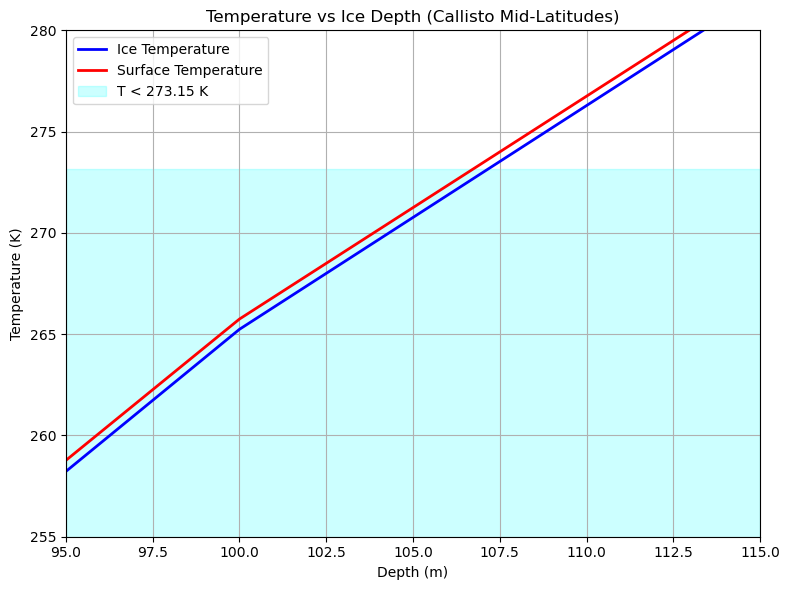

In [486]:
plt.figure(figsize=(8, 6))
plt.plot(target_depths_ca, t_array_callisto, label='Ice Temperature', color='blue', linewidth=2)
plt.plot(target_depths_ca, t_conv_list_callisto, label='Surface Temperature', color='red', linewidth=2)
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (K)")
plt.ylim(bottom = 255, top=280)

plt.axhspan(0, 273.15, color='cyan', alpha=0.2, label='T < 273.15 K')

plt.xlim([95,115])
plt.title("Temperature vs Ice Depth (Callisto Mid-Latitudes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [488]:
depths_cm_ca = np.array(target_depths_ca) * 100  # Convert to cm

t_conv_array = np.array(t_conv_list_callisto).flatten()
t_ice_array = np.array(t_array_callisto)

ice_interp = interp1d(depths_cm_ca, t_ice_array, kind='linear', bounds_error=False)
conv_interp = interp1d(depths_cm_ca, t_conv_array, kind='linear', bounds_error=False)

for depth in range(0, 20000,1):
    val = ice_interp(depth)
    if val > 273.15:
        break

print(f"First depth where ice temp > 273.15 K: {depth} cm, temp: {val:.2f} K")

First depth where ice temp > 273.15 K: 10717 cm, temp: 273.16 K


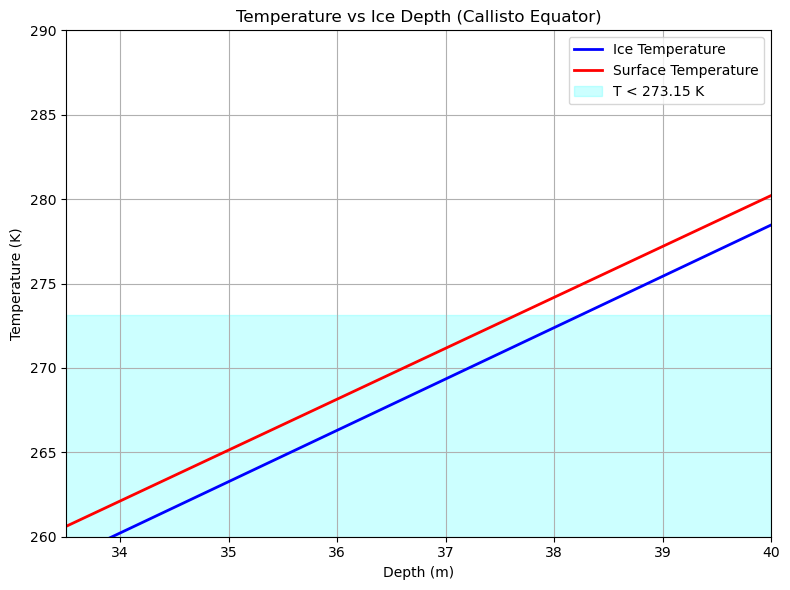

In [490]:
plt.figure(figsize=(8, 6))
plt.plot(target_depths_ca, t_array_callisto_equ, label='Ice Temperature', color='blue', linewidth=2)
plt.plot(target_depths_ca, t_conv_list_callisto_equ, label='Surface Temperature', color='red', linewidth=2)
plt.xlabel("Depth (m)")
plt.ylabel("Temperature (K)")
plt.ylim(bottom = 260, top=290)

plt.axhspan(0, 273.15, color='cyan', alpha=0.2, label='T < 273.15 K')

plt.xlim([33.5,40])
plt.title("Temperature vs Ice Depth (Callisto Equator)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [492]:
depths_cm_ca_equ = np.array(target_depths_ca) * 100  # Convert to cm

t_ice_array_equ = np.array(t_array_callisto_equ)

ice_interp_equ = interp1d(depths_cm_ca_equ, t_ice_array_equ, kind='linear', bounds_error=False)

for depth in range(0, 20000,1):
    val = ice_interp_equ(depth)
    if val > 273.15:
        break

print(f"First depth where ice temp > 273.15 K: {depth} cm, temp: {val:.2f} K")

First depth where ice temp > 273.15 K: 3826 cm, temp: 273.18 K


## Ansys Ice Earth vs. Theoretical Model (Without Constant Heat Generation) ##

In [354]:
data_celsius_plain = np.array([
    [0.0, -18.736],
    [0.020833, -17.876],
    [0.041667, -17.001],
    [0.0625, -16.11],
    [0.083333, -15.203],
    [0.10417, -14.281],
    [0.125, -13.343],
    [0.14583, -12.378],
    [0.16667, -11.396],
    [0.1875, -10.396],
    [0.20833, -9.379],
    [0.22917, -8.3439],
    [0.25, -7.2911],
    [0.27083, -6.2204],
    [0.29167, -5.1319],
    [0.3125, -4.0198],
    [0.33333, -2.884],
    [0.35417, -1.7286],
    [0.375, -0.55384],
    [0.39583, 0.64039],
    [0.41667, 1.8541],
    [0.4375, 3.0872],
    [0.45833, 4.3397],
    [0.47917, 5.6117],
    [0.5, 6.9032],
    [0.52083, 8.2141],
    [0.54167, 9.5444],
    [0.5625, 10.872],
    [0.58333, 12.246],
    [0.60417, 13.667],
    [0.625, 15.133],
    [0.64583, 16.645],
    [0.66667, 18.204],
    [0.6875, 19.809],
    [0.70833, 21.459],
    [0.72917, 23.156],
    [0.75, 24.898],
    [0.77083, 26.687],
    [0.79167, 28.522],
    [0.8125, 30.403],
    [0.83333, 32.33],
    [0.85417, 34.303],
    [0.875, 36.322],
    [0.89583, 38.387],
    [0.91667, 40.498],
    [0.9375, 42.655],
    [0.95833, 44.879],
    [0.97917, 47.152],
    [1.0, 49.495]
])


data_kelvin_plain = data_celsius_plain.copy()
data_kelvin_plain[:, 1] += 273.15

In [358]:
t_array_earth_new = np.array(t_array_earth)

earth_depth_resampled = np.linspace(min(target_depths_e), max(target_depths_e), data_kelvin_plain.shape[0])
interp_fun = interp1d(target_depths_e, t_array_earth_new, kind='linear', fill_value='extrapolate')
t_earth_resampled = interp_fun(earth_depth_resampled)

print(earth_depth_resampled.shape, t_earth_resampled.shape)

(49,) (49,)


In [360]:
difference_pred = t_earth_resampled - data_kelvin_plain[:,1]

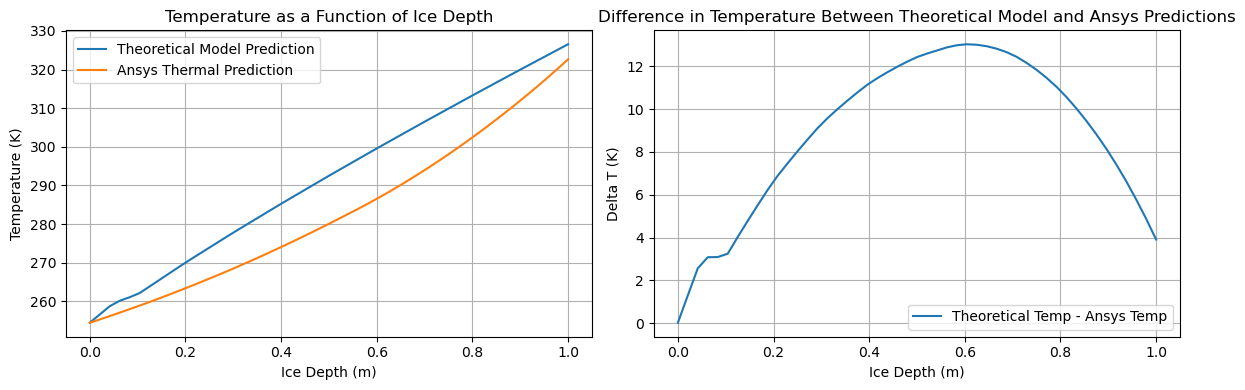

In [362]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(earth_depth_resampled, t_earth_resampled, label='Theoretical Model Prediction')
ax[0].plot(data_kelvin_plain[:,0], data_kelvin_plain[:,1], label = 'Ansys Thermal Prediction')
ax[0].set_xlabel('Ice Depth (m)')
ax[0].set_ylabel('Temperature (K)')
ax[0].set_title('Temperature as a Function of Ice Depth')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(earth_depth_resampled, difference_pred, label='Theoretical Temp - Ansys Temp')
ax[1].set_xlabel('Ice Depth (m)')
ax[1].set_ylabel('Delta T (K)')
ax[1].set_title('Difference in Temperature Between Theoretical Model and Ansys Predictions')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

## Ansys Ice Mars vs. Theoretical Model (With constant heat generation) ##

In [364]:
data_mars = np.array([
    (0.0, -57.801),
    (0.020833, -56.944),
    (0.041667, -56.133),
    (0.0625, -55.329),
    (0.083333, -54.528),
    (0.10417, -53.729),
    (0.125, -52.558),
    (0.14583, -51.742),
    (0.16667, -50.924),
    (0.1875, -50.072),
    (0.20833, -48.95),
    (0.22917, -48.143),
    (0.25, -47.341),
    (0.27083, -46.527),
    (0.29167, -45.781),
    (0.3125, -44.877),
    (0.33333, -44.197),
    (0.35417, -43.378),
    (0.375, -42.5),
    (0.39583, -41.802),
    (0.41667, -41.313),
    (0.4375, -40.707),
    (0.45833, -40.101),
    (0.47917, -39.509),
    (0.5, -38.929),
    (0.52083, -37.856),
    (0.54167, -37.294),
    (0.5625, -36.724),
    (0.58333, -36.163),
    (0.60417, -35.397),
    (0.625, -34.972),
    (0.64583, -34.418),
    (0.66667, -33.867),
    (0.6875, -33.417),
    (0.70833, -32.772),
    (0.72917, -32.396),
    (0.75, -31.968),
    (0.77083, -31.484),
    (0.79167, -31.01),
    (0.8125, -30.47),
    (0.83333, -30.115),
    (0.85417, -29.787),
    (0.875, -29.489),
    (0.89583, -29.214),
    (0.91667, -28.346),
    (0.9375, -28.039),
    (0.95833, -27.751),
    (0.97917, -27.472),
    (1.0, -27.166)
])

data_kelvin_mars = data_mars.copy()
data_kelvin_mars[:, 1] += 273.15

In [366]:
t_array_mars_new = np.array(t_array_mars[0:11])

mars_depth_resampled = np.linspace(min(target_depths_m[0:11]), max(target_depths_m[0:11]), data_kelvin_mars.shape[0])
interp_fun = interp1d(target_depths_m[0:11], t_array_mars_new, kind='linear', fill_value='extrapolate')
t_mars_resampled = interp_fun(mars_depth_resampled)

print(mars_depth_resampled.shape, t_mars_resampled.shape)

difference_pred_mars = t_mars_resampled - data_kelvin_mars[:,1]

(49,) (49,)


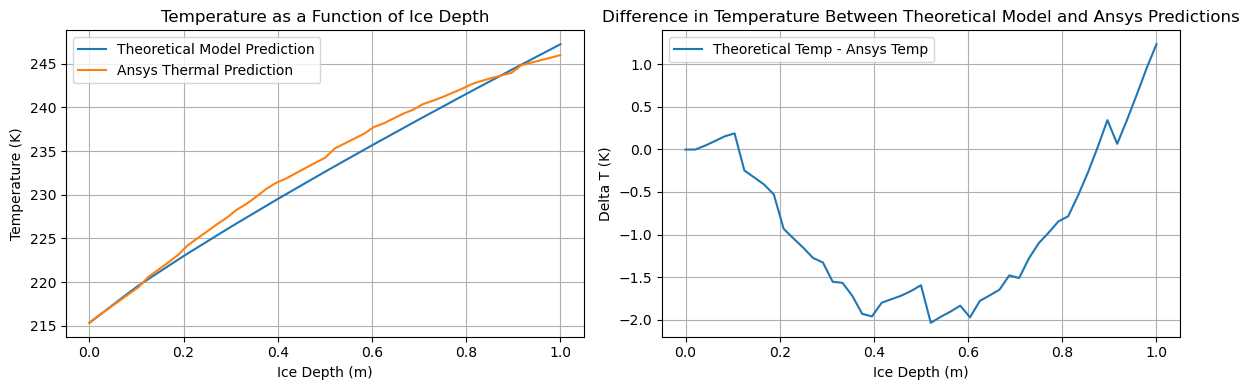

In [368]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(mars_depth_resampled, t_mars_resampled, label='Theoretical Model Prediction')
ax[0].plot(data_kelvin_mars[:,0], data_kelvin_mars[:,1], label = 'Ansys Thermal Prediction')
ax[0].set_xlabel('Ice Depth (m)')
ax[0].set_ylabel('Temperature (K)')
ax[0].set_title('Temperature as a Function of Ice Depth')
ax[0].grid(True)
ax[0].legend()

ax[1].plot(mars_depth_resampled, difference_pred_mars, label='Theoretical Temp - Ansys Temp')
ax[1].set_xlabel('Ice Depth (m)')
ax[1].set_ylabel('Delta T (K)')
ax[1].set_title('Difference in Temperature Between Theoretical Model and Ansys Predictions')
ax[1].grid(True)
ax[1].legend()

# ax[1].set_xlim(0, 0.03)
# ax[1].set_ylim(-0.1, 0)

plt.tight_layout()
plt.show()